# CellRegPy — Full Pipeline Demo (Dual-Model Final Registration)

This notebook runs the *full* `CellRegPy` pipeline on a mouse folder (session subfolders),
and **enforces the Stage‑6 dual-model final registration**:

1. **Centroid-distance probabilistic model** drives clustering  
2. **Spatial correlation** is used only as a **post-hoc veto** (floor cutoff, default **0.5**)
3. **Intersection over union** is used only in the rare cases where two images are near perfectly aligned (>0.9) to prevent mixed model failure

During the run, figures are generated (matching the `demo_validate_alignment` figure set),
but **Stage 4/5 plots are omitted**. Instead, a **Stage 6 (dual)** summary is saved per FOV:
- centroid distance histogram (accepted vs vetoed)
- spatial correlation histogram (accepted vs vetoed, floor shown)
- final registered projections + pairwise overlap

All figures are saved to:  
`<mouse_folder>/1_CellReg/FOV*/Figures/`  
and are **closed automatically** when `figures_visibility='off'` to avoid graphics crashes.


In [4]:
from pathlib import Path
import sys

# If you are running this notebook from the repo root, keep this.
# Otherwise, set this to the folder that contains cellregpy.py
repo_root = Path.cwd()
sys.path.insert(0, str(repo_root))

from cellregpy import CellRegConfig, run_pipeline


In [5]:
# ---- USER INPUT ----
mouse_folder = Path(r"C:\Users\spell\SpellmanLab Dropbox\OtherData\Manuscripts\in prep\L6CTopto_panneuronal_experiment\data\subjects_L6REstim\L629_M_LeftPFC_L6REChrimson_Panrec")  # e.g. r"C:\...\L612_F_RightPFC_..."

cfg = CellRegConfig()
cfg.microns_per_pixel = 2.0
cfg.maximal_distance = 14.0
cfg.p_same_threshold = 0.5

cfg.save_figures = True
cfg.figures_visibility = "on"
cfg.also_pdf = True
cfg.test_run = False

# Disable old correlation-based auto-simple gate (avoid conflicts)
cfg.auto_simple_on_high_similarity = False

# Enable peak-based gate
cfg.auto_flex_on_high_peak = True
cfg.auto_flex_peak_threshold = 0.95

# Ensure we actually use IoU+Hungarian
cfg.auto_simple_method = "iou_hungarian"

# IoU knobs
cfg.simple_mask_threshold = 0.15
cfg.simple_iou_threshold  = 0.10
cfg.simple_cost_beta = 0.25


Processing: C:\Users\spell\SpellmanLab Dropbox\OtherData\Manuscripts\in prep\L6CTopto_panneuronal_experiment\data\subjects_L6REstim\L629_M_LeftPFC_L6REChrimson_Panrec
Beginning processing: C:\Users\spell\SpellmanLab Dropbox\OtherData\Manuscripts\in prep\L6CTopto_panneuronal_experiment\data\subjects_L6REstim\L629_M_LeftPFC_L6REChrimson_Panrec
Stage 1: Loading 2 sessions
Loading mean images and iscell data...
Building spatial-footprint projection images (iscell-filtered)...
  Loaded footprints from key 'footprints'
  Loaded footprints from key 'footprints'
Adjusting FOV sizes...
Finding alignable sessions...
  Testing session 1/2 as reference
  Testing session 2/2 as reference
Saving alignment graph to C:\Users\spell\SpellmanLab Dropbox\OtherData\Manuscripts\in prep\L6CTopto_panneuronal_experiment\data\subjects_L6REstim\L629_M_LeftPFC_L6REChrimson_Panrec\1_CellReg\alignable_sessions_graph.png
Removing redundancies...
  Kept 1/2 FOVs
Working on FOV 1/1
  Registering 2 sessions...
  Loaded

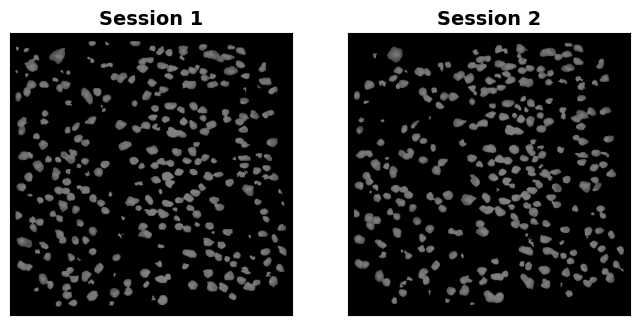

Computing footprint projections...
  Session 1/2
  Session 2/2


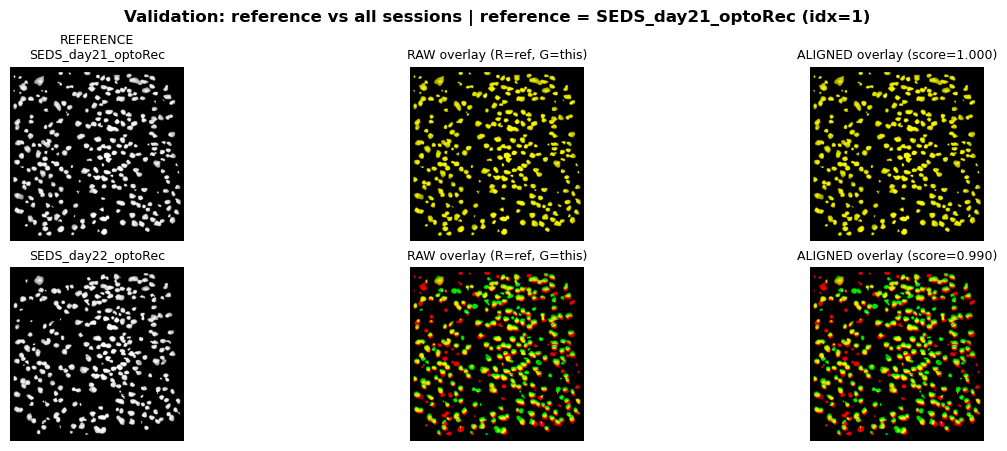

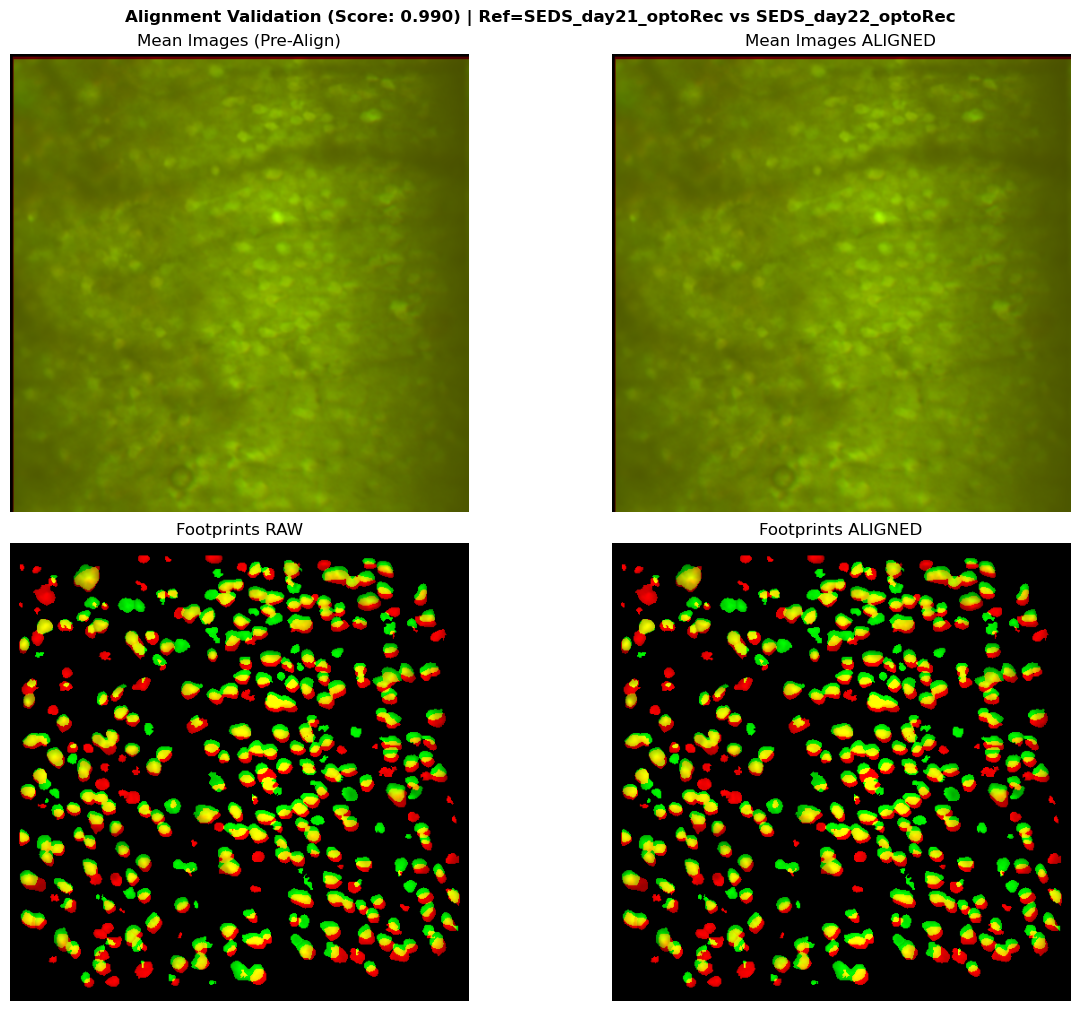

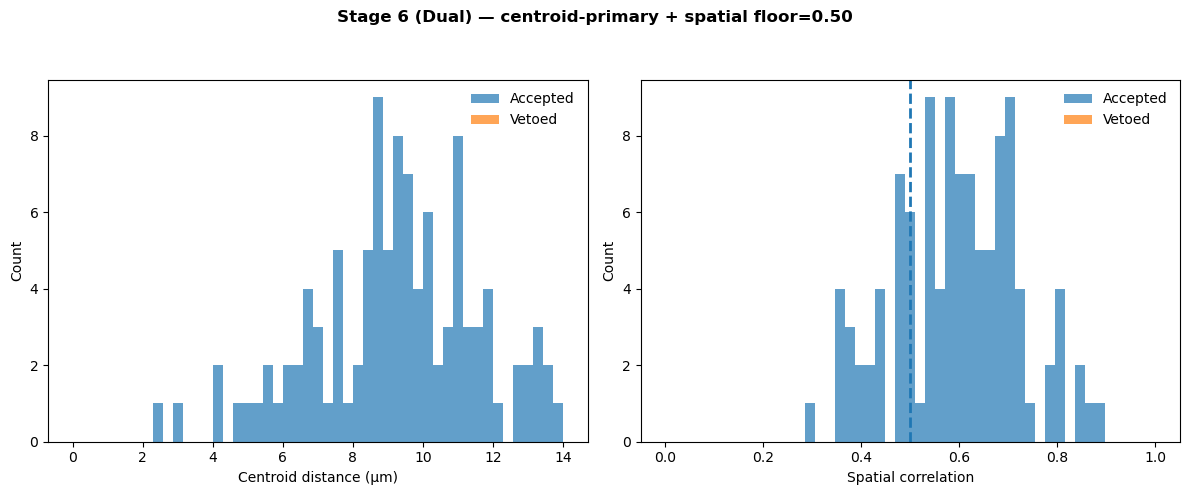

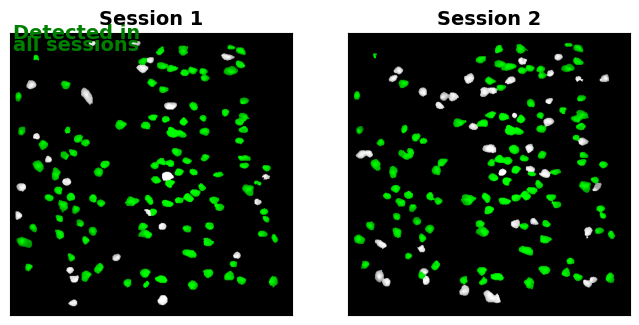

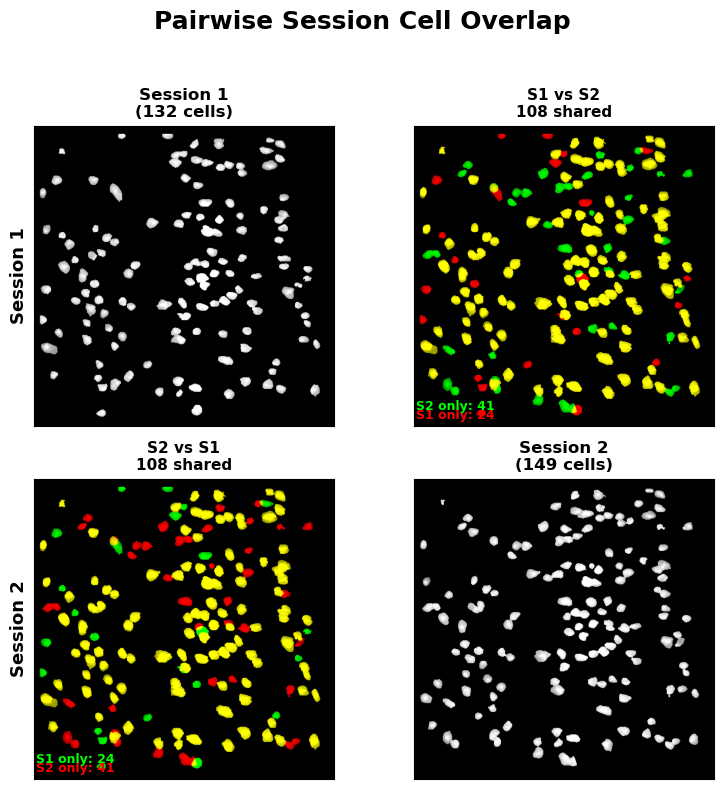

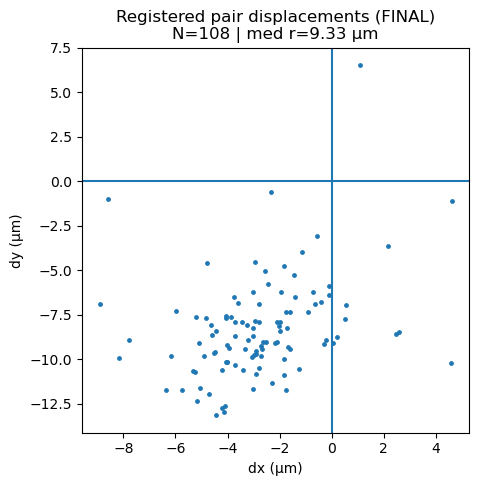

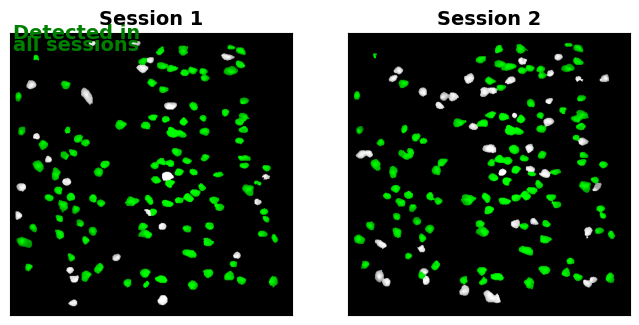

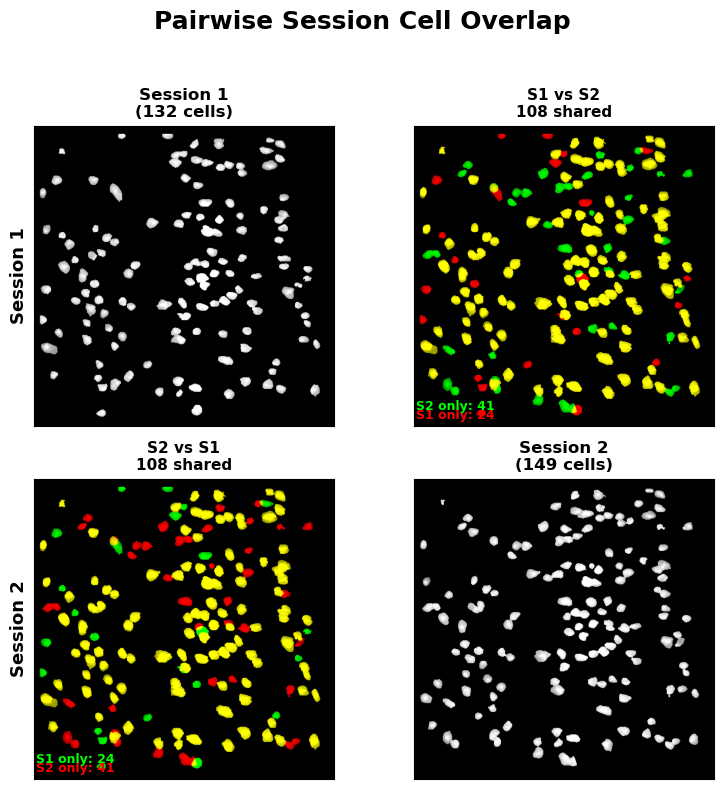

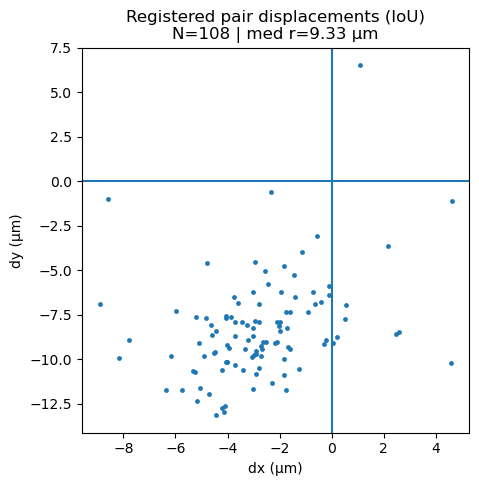

  ✓ Registered 173 cell clusters across 2 sessions
mouse_table shape: (281, 7)
mouse_table columns: ['MouseName', 'Session', 'UnixTime', 'suite2pID', 'cellRegID', 'fovID', 'SessionPath']
n sessions: 2


C:\Users\spell\SpellmanLab Dropbox\timspellman\Python\John\CellRegPy\cellregpy\cellregpy.py:3561: UserWarning: Could not save mouse_table.mat: Could not convert None (type <class 'NoneType'>) to array
  warnings.warn(f"Could not save mouse_table.mat: {e}")


,n_cells
Session,
SEDS_day22_optoRec,149
SEDS_day21_optoRec,132


In [6]:
# ---- RUN FULL PIPELINE (dual-model enforced inside run_pipeline) ----
mouse_table, mouse_data = run_pipeline(
    mouse_folder,
    cfg=cfg,
    spatial_corr_floor=cfg.spatial_corr_floor,
    save_figures=cfg.save_figures,
    figures_visibility=cfg.figures_visibility,
    export_csv=True,
)

print("mouse_table shape:", mouse_table.shape)
print("mouse_table columns:", list(mouse_table.columns))
print("n sessions:", mouse_table["Session"].nunique())

# show how many cells per session (top 10)
(mouse_table.groupby("Session")
           .size()
           .sort_values(ascending=False)
           .head(10)
           .to_frame("n_cells"))


In [7]:
mouse_table

,MouseName,Session,UnixTime,suite2pID,cellRegID,fovID,SessionPath
0,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day21_optoRec,None,1,1,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
1,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day21_optoRec,None,2,2,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
2,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day21_optoRec,None,5,3,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
3,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day21_optoRec,None,7,4,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
4,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day21_optoRec,None,8,5,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
...,...,...,...,...,...,...,...
276,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day22_optoRec,None,269,129,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
277,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day22_optoRec,None,270,170,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
278,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day22_optoRec,None,272,171,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...
279,L629_M_LeftPFC_L6REChrimson_Panrec,SEDS_day22_optoRec,None,275,172,[1],C:\Users\spell\SpellmanLab Dropbox\OtherData\M...


In [8]:
# ---- Wide table (nice for MATLAB) ----
wide = (mouse_table
        .pivot_table(index="cellRegID", columns="Session", values="suite2pID",
                     aggfunc="first", fill_value=0)
        .sort_index())
print("wide shape:", wide.shape)
# preview up to first 10 cellRegIDs and up to 10 sessions
wide.iloc[:10, :min(10, wide.shape[1])]


wide shape: (173, 2)


Session,SEDS_day21_optoRec,SEDS_day22_optoRec
cellRegID,,
1,1,0
2,2,0
3,5,1
4,7,2
5,8,4
6,10,3
7,15,0
8,16,10
9,19,0


Previewing figures in: C:\Users\spell\SpellmanLab Dropbox\OtherData\Manuscripts\in prep\L6CTopto_panneuronal_experiment\data\subjects_L6REstim\L629_M_LeftPFC_L6REChrimson_Panrec\1_CellReg\FOV1\Figures


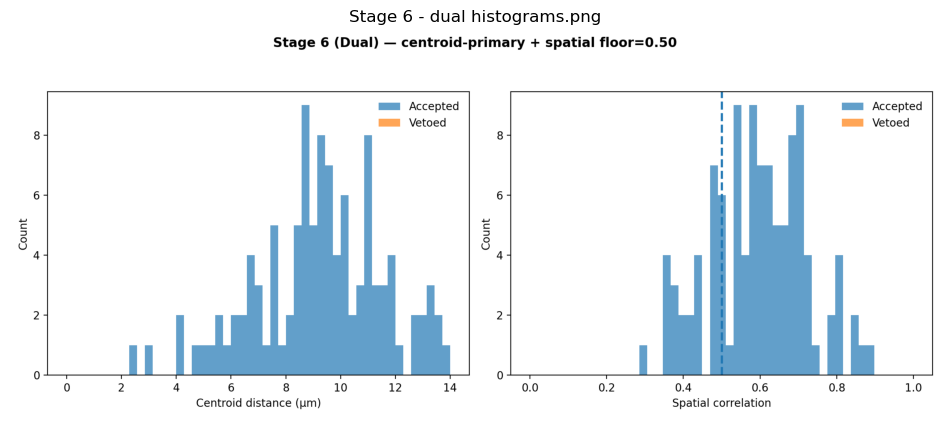

Missing: Stage 6 (dual) - registered projections.png
Missing: Stage 6 - pairwise session overlap.png
Missing: Stage 2 - Validation reference vs all sessions.png
Missing: Stage X - simple mode QC.png


In [9]:
# ---- Preview Stage 6 figures for the first FOV (if present) ----
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

cellreg_root = mouse_folder / "1_CellReg"
fov_dirs = sorted([p for p in cellreg_root.glob("FOV*") if p.is_dir()])

if not fov_dirs:
    print("No FOV folders found under:", cellreg_root)
else:
    fig_dir = fov_dirs[0] / "Figures"
    print("Previewing figures in:", fig_dir)

    # Stage 6 hist + projections are the most informative for the dual workflow
    candidates = [
        # Dual-model figures (probabilistic path)
        fig_dir / "Stage 6 - dual histograms.png",
        fig_dir / "Stage 6 (dual) - registered projections.png",
        fig_dir / "Stage 6 - pairwise session overlap.png",

        # Simple-mode figures (auto-simple path)
        fig_dir / "Stage 2 - Validation reference vs all sessions.png",
        fig_dir / "Stage X - simple mode QC.png",
    ]

    for p in candidates:
        if p.exists():
            img = mpimg.imread(p)
            plt.figure(figsize=(12, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.title(p.name)
            plt.show()
        else:
            print("Missing:", p.name)


## Where outputs go

- **Per‑FOV results:** `<mouse_folder>/1_CellReg/FOV*/Results/`  
  - `cell_to_index_map.npy` (FINAL, post spatial-floor veto)
  - `cell_to_index_map_pre_spatial_floor.npy` (centroid-primary, pre-veto)  
  - `registration_results.npy` (includes veto stats / arrays)

- **Per‑FOV figures:** `<mouse_folder>/1_CellReg/FOV*/Figures/`  
  - Stage 1–3 figures (as in `demo_validate_alignment`)
  - **Stage 6 (dual) summary** (replaces Stage 4/5 plotting)

- **Mouse table exports:** `<mouse_folder>/1_CellReg/`  
  - `mouse_table.csv`
  - `mouse_table_wide.csv`
  - plus existing `mouse_table.mat` / `mouse_table.pkl`
